In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/rapido_project/data/captain_synthetic.csv')
sns.set_theme(style='darkgrid')
colors = {'churned': '#FF4B4B', 'active': '#00C49A'}

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['is_churned'].mean():.2%}")

Mounted at /content/drive
Dataset shape: (10000, 24)
Churn rate: 41.06%


In [2]:
decay = df.groupby('is_churned')[
    ['rides_week1','rides_week2','rides_week3','rides_week4']
].mean().T

decay.columns = ['Active', 'Churned']
decay.index = ['Week 1', 'Week 2', 'Week 3', 'Week 4']

fig = px.line(
    decay,
    markers=True,
    title='🚨 Ride Decay Curve — Churned vs Active Captains',
    labels={'value': 'Avg Rides', 'index': 'Week'},
    color_discrete_map={'Active': '#00C49A', 'Churned': '#FF4B4B'}
)
fig.show()

In [3]:
churn_city = df.groupby(['city','vehicle_type'])['is_churned'].mean().reset_index()
churn_city['churn_pct'] = (churn_city['is_churned'] * 100).round(1)

fig = px.bar(
    churn_city,
    x='city',
    y='churn_pct',
    color='vehicle_type',
    barmode='group',
    title='Churn Rate by City and Vehicle Type',
    labels={'churn_pct': 'Churn Rate (%)'},
    color_discrete_map={'bike': '#FF4B4B', 'auto': '#4B9FFF'}
)
fig.show()

In [4]:
churn_type = df.groupby('captain_type')['is_churned'].mean().reset_index()
churn_type['churn_pct'] = (churn_type['is_churned'] * 100).round(1)

fig = px.bar(
    churn_type,
    x='captain_type',
    y='churn_pct',
    color='captain_type',
    title='Parttime Captains Churn Significantly More',
    labels={'churn_pct': 'Churn Rate (%)'},
    color_discrete_map={'fulltime': '#00C49A', 'parttime': '#FF4B4B'},
    text='churn_pct'
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

In [5]:
fig = px.box(
    df,
    x='is_churned',
    y='rides_week4',
    color='is_churned',
    title='Week 4 Rides — Churned vs Active',
    labels={'rides_week4': 'Rides in Week 4'},
    color_discrete_map={0: '#00C49A', 1: '#FF4B4B'}
)
fig.update_xaxes(ticktext=['Active', 'Churned'], tickvals=[0, 1])
fig.update_layout(showlegend=False)
fig.show()

In [11]:
fig = px.box(
    df,
    x='is_churned',
    y='cancellation_rate',
    color='is_churned',
    title='Cancellation Rate — Churned vs Active',
    labels={
        'cancellation_rate': 'Cancellation Rate',
        'is_churned': 'Status'
    },
    color_discrete_map={0: '#00C49A', 1: '#FF4B4B'}
)
fig.update_xaxes(ticktext=['Active', 'Churned'], tickvals=[0, 1])
fig.update_layout(showlegend=False, height=400)
fig.show()

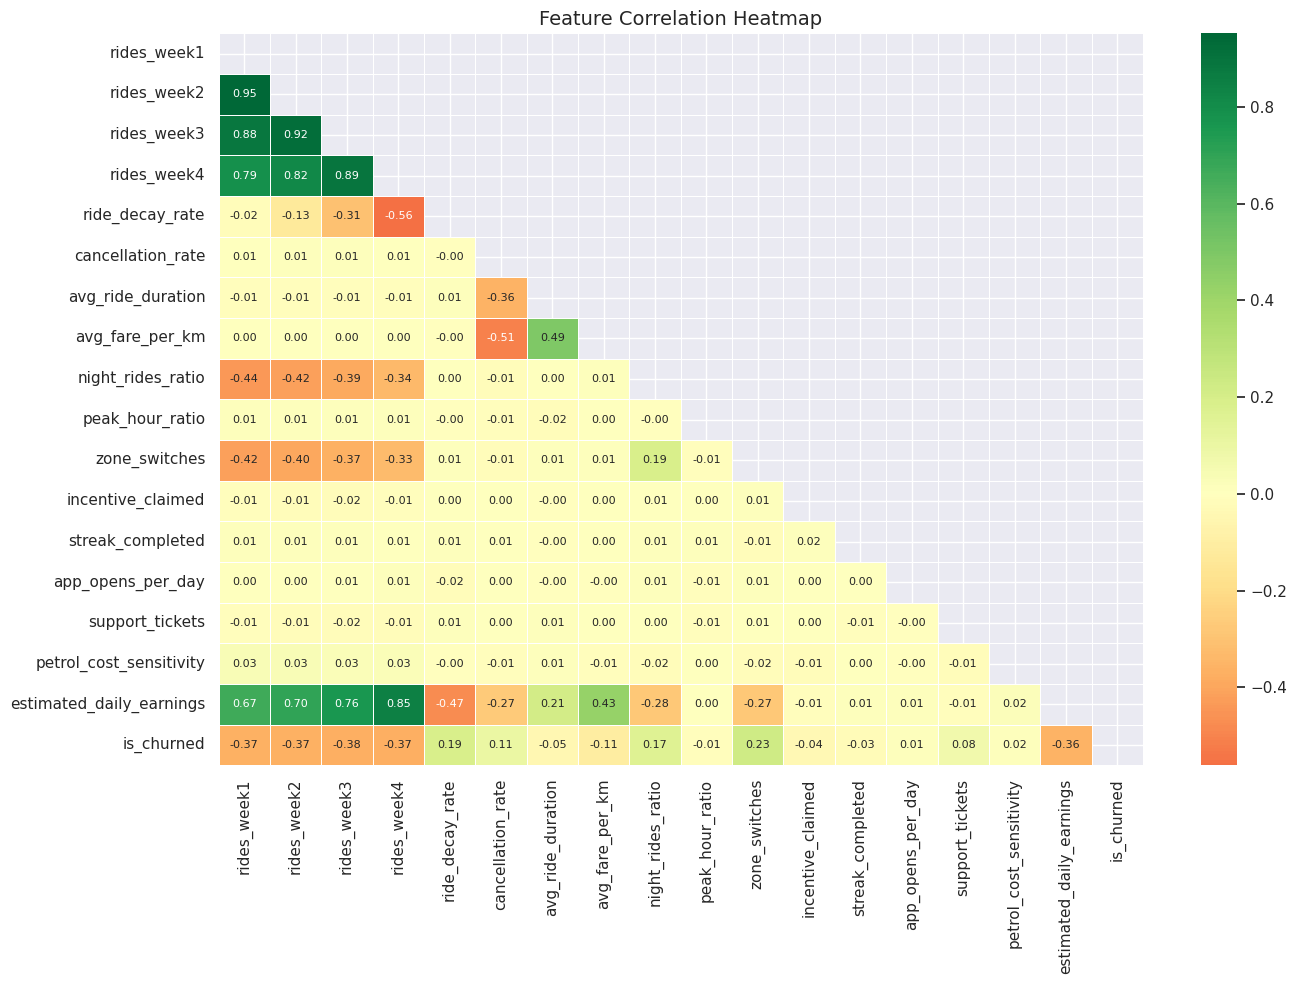


Top correlations with churn:
rides_week3                -0.375461
rides_week4                -0.374268
rides_week2                -0.370448
rides_week1                -0.369440
estimated_daily_earnings   -0.356966
avg_fare_per_km            -0.108304
avg_ride_duration          -0.050368
incentive_claimed          -0.040127
streak_completed           -0.025621
peak_hour_ratio            -0.005727
app_opens_per_day           0.008089
petrol_cost_sensitivity     0.015726
support_tickets             0.076150
cancellation_rate           0.106344
night_rides_ratio           0.165147
ride_decay_rate             0.192902
zone_switches               0.228621
is_churned                  1.000000
Name: is_churned, dtype: float64


In [7]:
numeric_cols = [
    'rides_week1','rides_week2','rides_week3','rides_week4',
    'ride_decay_rate','cancellation_rate','avg_ride_duration',
    'avg_fare_per_km','night_rides_ratio','peak_hour_ratio',
    'zone_switches','incentive_claimed','streak_completed',
    'app_opens_per_day','support_tickets',
    'petrol_cost_sensitivity','estimated_daily_earnings','is_churned'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop correlations with churn:")
print(corr['is_churned'].sort_values())

In [13]:
print("5 KEY EDA INSIGHTS FOR RAPIDO")
print("=" * 45)

print("\n1. RIDE DECAY IS THE #1 SIGNAL")
print("   Churned captains crash from 37 to 10 rides by Week 4")
print("   Active captains hold at 57 to 19 rides")
print("   Gap widens every week and is detectable by Week 2")

print("\n2. BIKE CAPTAINS ARE HIGH RISK")
print("   Bike churn 44% vs Auto churn 33%")
print("   Lower fare per km (Rs.11 vs Rs.19) means thinner margins")

print("\n3. PARTTIME CAPTAINS ARE A FLIGHT RISK")
print("   Parttime churn 56% vs Fulltime 19%")
print("   Low switching cost and side hustle mindset drives dropout")

print("\n4. WEEK 4 RIDES IS THE CLEAREST SEPARATOR")
print("   Churned median: 9 rides")
print("   Active median: 19 rides — a 2x difference")

print("\n5. EARNINGS DRIVES RETENTION MORE THAN BEHAVIOUR")
print("   Daily earnings correlation with churn: -0.36")
print("   Cancellation rate correlation: only 0.11")
print("   Fix earnings first, not cancellations")

5 KEY EDA INSIGHTS FOR RAPIDO

1. RIDE DECAY IS THE #1 SIGNAL
   Churned captains crash from 37 to 10 rides by Week 4
   Active captains hold at 57 to 19 rides
   Gap widens every week and is detectable by Week 2

2. BIKE CAPTAINS ARE HIGH RISK
   Bike churn 44% vs Auto churn 33%
   Lower fare per km (Rs.11 vs Rs.19) means thinner margins

3. PARTTIME CAPTAINS ARE A FLIGHT RISK
   Parttime churn 56% vs Fulltime 19%
   Low switching cost and side hustle mindset drives dropout

4. WEEK 4 RIDES IS THE CLEAREST SEPARATOR
   Churned median: 9 rides
   Active median: 19 rides — a 2x difference

5. EARNINGS DRIVES RETENTION MORE THAN BEHAVIOUR
   Daily earnings correlation with churn: -0.36
   Cancellation rate correlation: only 0.11
   Fix earnings first, not cancellations
